<a href="https://colab.research.google.com/github/EngAI2222/ABUKHALED/blob/main/YOLO11m_Tomato_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Wed Jul 22 13:28:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q ultralytics kaggle

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.4 MB/s eta 0:00:00


In [ ]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 46.7/112.6 GB disk)


In [5]:
!pip install -q kagglehub

import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "yusufmurtaza01/tomato-leaf-dataset-for-disease-detection"
)

print("Path:", path)

100%|██████████| 280M/280M [00:05<00:00, 54.0MB/s]

Extracting files...


Path: /root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-dataset-for-disease-detection/versions/2


In [6]:
#البيانات المطاط#
import os

for root, dirs, files in os.walk(path):
    print(root)
    if len(files):
        print("Files:", files[:10])  # يعرض أول 10 ملفات فقط
    print("-" * 50)

/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-dataset-for-disease-detection/versions/2
Files: ['class_distribution_val.png', 'tomato_data.ipynb', 'class_distribution_train.png']
--------------------------------------------------
/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-dataset-for-disease-detection/versions/2/tomato_yolo_dataset
--------------------------------------------------
/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-dataset-for-disease-detection/versions/2/tomato_yolo_dataset/labels
--------------------------------------------------
/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-dataset-for-disease-detection/versions/2/tomato_yolo_dataset/labels/val
Files: ['TMYC_image (1670).txt', 'TMBS_image (1561).txt', 'TMSL_image (1252).txt', 'TMLM_image (486).txt', 'TMYC_image (4959).txt', 'TMYC_image (1864).txt', 'TMTS_image (954).txt', 'TMYC_image (3010).txt', 'TMTS_image (1351).txt', 'TMYC_image (1533).txt']
----------------------

In [7]:
from pathlib import Path

yaml_files = list(Path(path).glob("**/*.yaml"))

print("عدد ملفات YAML:", len(yaml_files))

for f in yaml_files:
    print(f)

عدد ملفات YAML: 0


In [8]:
from pathlib import Path

labels_path = Path(path) / "tomato_yolo_dataset" / "labels" / "train"

classes = set()

for txt_file in labels_path.glob("*.txt"):
    with open(txt_file, "r") as f:
        for line in f:
            if line.strip():
                cls = int(line.split()[0])
                classes.add(cls)

print("عدد الفئات:", len(classes))
print("الفئات:", sorted(classes))

عدد الفئات: 10
الفئات: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [9]:
#انشاء ملف yaml#
from pathlib import Path

dataset_path = Path(path) / "tomato_yolo_dataset"

yaml_content = f"""
path: {dataset_path}
train: images/train
val: images/val

names:
  0: Bacterial Spot
  1: Early Blight
  2: Late Blight
  3: Leaf Mold
  4: Septoria Leaf Spot
  5: Spider Mites
  6: Target Spot
  7: Yellow Leaf Curl Virus
  8: Mosaic Virus
  9: Healthy
"""

yaml_file = dataset_path / "data.yaml"

with open(yaml_file, "w") as f:
    f.write(yaml_content)

print("✅ تم إنشاء الملف:")
print(yaml_file)

✅ تم إنشاء الملف:
/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-dataset-for-disease-detection/versions/2/tomato_yolo_dataset/data.yaml


In [10]:
print(open(yaml_file).read())


path: /root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-dataset-for-disease-detection/versions/2/tomato_yolo_dataset
train: images/train
val: images/val

names:
  0: Bacterial Spot
  1: Early Blight
  2: Late Blight
  3: Leaf Mold
  4: Septoria Leaf Spot
  5: Spider Mites
  6: Target Spot
  7: Yellow Leaf Curl Virus
  8: Mosaic Virus
  9: Healthy



In [11]:
import os
from collections import Counter

train_images = os.path.join(dataset_path, "images", "train")
train_labels = os.path.join(dataset_path, "labels", "train")

image_count = len([f for f in os.listdir(train_images) if f.endswith((".jpg", ".png", ".jpeg"))])
label_count = len([f for f in os.listdir(train_labels) if f.endswith(".txt")])

print("عدد صور التدريب:", image_count)
print("عدد ملفات الليبل:", label_count)

counter = Counter()

for file in os.listdir(train_labels):
    if file.endswith(".txt"):
        with open(os.path.join(train_labels, file)) as f:
            for line in f:
                if line.strip():
                    cls = int(line.split()[0])
                    counter[cls] += 1

print("\nعدد العينات لكل فئة:")
for cls, num in sorted(counter.items()):
    print(f"Class {cls}: {num}")

عدد صور التدريب: 14526
عدد ملفات الليبل: 14526

عدد العينات لكل فئة:
Class 0: 1700
Class 1: 785
Class 2: 1531
Class 3: 761
Class 4: 1431
Class 5: 1356
Class 6: 1113
Class 7: 4277
Class 8: 301
Class 9: 1286


In [12]:
#في حال انقطع النت لا تضيع البيانات#
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
from ultralytics import YOLO

model = YOLO("yolo11m.pt")

results = model.train(
    data=str(yaml_file),
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    workers=8,
    cache=True,
    optimizer="auto",

    project="/content/drive/MyDrive/YOLO_Tomato",
    name="YOLO11m_Tomato",

    save=True,
    exist_ok=True,
    save_period=5,

    patience=20,
    plots=True
)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-dataset-for-disease-detection/versions/2/tomato_yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, mom

KeyboardInterrupt: 

In [14]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

weights = Path("/content/drive/MyDrive/YOLO_Tomato/YOLO11m_Tomato/weights")

print("last.pt:", (weights / "last.pt").exists())
print("best.pt:", (weights / "best.pt").exists())

for f in weights.glob("*"):
    print(f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
last.pt: True
best.pt: True
/content/drive/MyDrive/YOLO_Tomato/YOLO11m_Tomato/weights/last.pt
/content/drive/MyDrive/YOLO_Tomato/YOLO11m_Tomato/weights/best.pt
/content/drive/MyDrive/YOLO_Tomato/YOLO11m_Tomato/weights/epoch0.pt
/content/drive/MyDrive/YOLO_Tomato/YOLO11m_Tomato/weights/epoch5.pt
/content/drive/MyDrive/YOLO_Tomato/YOLO11m_Tomato/weights/epoch10.pt
/content/drive/MyDrive/YOLO_Tomato/YOLO11m_Tomato/weights/epoch15.pt
/content/drive/MyDrive/YOLO_Tomato/YOLO11m_Tomato/weights/epoch20.pt


🔍 جاري تقييم النموذج على مجموعة البيانات...
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,037,742 parameters, 0 gradients, 67.7 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 14.2±9.3 MB/s, size: 16.6 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-dataset-for-disease-detection/versions/2/tomato_yolo_dataset/labels/val.cache... 3632 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3632/3632 692.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 227/227 1.7it/s 2:12
                   all       3632       3638      0.993      0.991      0.994      0.984
        Bacterial Spot        427        427      0.987      0.993      0.995      0.991
       

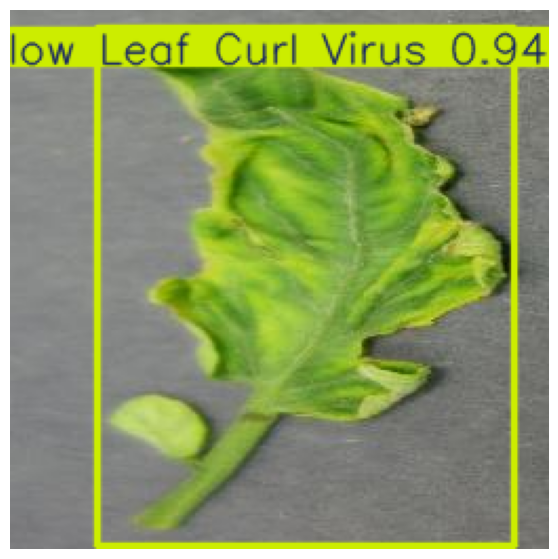


image 1/1 /root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-dataset-for-disease-detection/versions/2/tomato_yolo_dataset/images/val/TMLM_image (461).jpg: 640x640 1 Leaf Mold, 37.0ms
Speed: 4.1ms preprocess, 37.0ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)


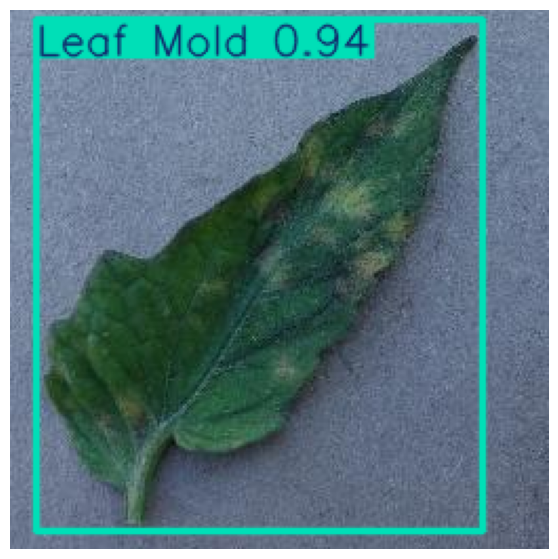


image 1/1 /root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-dataset-for-disease-detection/versions/2/tomato_yolo_dataset/images/val/TMYC_image (303).jpg: 640x640 1 Yellow Leaf Curl Virus, 37.0ms
Speed: 4.6ms preprocess, 37.0ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)


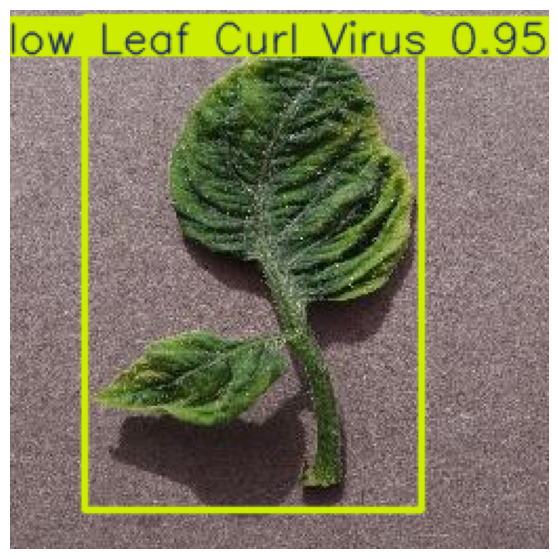

In [15]:
import glob
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. تحميل أفضل نموذج تم حفظه
best_model_path = "/content/drive/MyDrive/YOLO_Tomato/YOLO11m_Tomato/weights/best.pt"
model = YOLO(best_model_path)

# 2. تقييم شامل لحساب الدقة النهائية (mAP)
print("🔍 جاري تقييم النموذج على مجموعة البيانات...")
metrics = model.val(
    data="/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-dataset-for-disease-detection/versions/2/tomato_yolo_dataset/data.yaml"
)

print("\n-------------------------------------------")
print(f"📊 mAP50    : {metrics.box.map50 * 100:.2f}%")
print(f"📊 mAP50-95 : {metrics.box.map * 100:.2f}%")
print("-------------------------------------------\n")

# 3. عرض 3 صور اختبار عشوائية لرؤية التنبؤات بعينك
val_images = glob.glob(
    "/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-dataset-for-disease-detection/versions/2/tomato_yolo_dataset/images/val/*.jpg"
)
sample_images = random.sample(val_images, min(3, len(val_images)))

for img_path in sample_images:
    results = model.predict(source=img_path, conf=0.4)
    res_plotted = cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(7, 7))
    plt.imshow(res_plotted)
    plt.axis("off")
    plt.show()